In [1]:
import certifi
import os

os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

import cfbd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

configuration = cfbd.Configuration(
    access_token=os.environ['CFBD_API_KEY']
)
api_config = cfbd.ApiClient(configuration)

teams_api = cfbd.TeamsApi(api_config)
games_api = cfbd.GamesApi(api_config)
plays_api = cfbd.PlaysApi(api_config)

pd.set_option('display.max_colwidth', None)

In [ ]:
"""
all_plays = []
for year in range(2005, 2025):
    if year == 2020:
        continue
    for week in range(1, 16):
        try:
            plays = plays_api.get_plays(year=year, week=week, team='California', season_type='regular')
            for p in plays:
                play_dict = p.to_dict()
                play_dict['year'] = year
                all_plays.append(play_dict)
        except Exception as e:
            print(f"{year} week {week} failed: {e}")

df = pd.DataFrame.from_records(all_plays)
"""

'\nall_plays = []\nfor year in range(2005, 2025):\n    if year == 2020:\n        continue\n    for week in range(1, 16):\n        try:\n            plays = plays_api.get_plays(year=year, week=week, team=\'California\', season_type=\'regular\')\n            for p in plays:\n                play_dict = p.to_dict()\n                play_dict[\'year\'] = year\n                all_plays.append(play_dict)\n        except Exception as e:\n            print(f"{year} week {week} failed: {e}")\n\ndf = pd.DataFrame.from_records(all_plays)\n'

In [ ]:
# df.to_csv('cal_plays_raw_with_year.csv', index=False)

In [2]:
df = pd.read_csv('cal_plays_raw_with_year.csv')

In [3]:
cal_offense = df[df['offense'] == 'California'].copy()

In [4]:
print(cal_offense.columns)

Index(['id', 'driveId', 'gameId', 'driveNumber', 'playNumber', 'offense',
       'offenseConference', 'offenseScore', 'defense', 'home', 'away',
       'defenseConference', 'defenseScore', 'period', 'clock', 'yardline',
       'yardsToGoal', 'down', 'distance', 'yardsGained', 'scoring', 'playType',
       'playText', 'ppa', 'offenseTimeouts', 'defenseTimeouts', 'wallclock',
       'year'],
      dtype='object')


In [ ]:
df2 = cal_offense[['playNumber','down', 'playType', 'yardsGained', 'playText']]
df2[df2['down'] == 1].sort_values(by = ['yardsGained'])

,playNumber,down,playType,yardsGained,playText
28572,9,1,Interception Return Touchdown,-100,"Ross Bowers pass intercepted for a TD Nick Fisher return for 100 yds for a TD, (James Stefanou KICK)"
23392,2,1,Interception Return Touchdown,-46,"Jared Goff pass intercepted for a TD Adoree' Jackson return for 46 yds for a TD, (Alex Wood KICK)"
21685,3,1,Pass Interception Return,-46,Luke Rubenzer pass intercepted Terrence Alexander return for 46 yds to the Cal 4
31271,6,1,Pass Interception Return,-43,Chase Garbers pass intercepted Paulson Adebo return for 43 yds to the Cal 3
30055,2,1,Pass Interception Return,-38,Brandon McIlwain pass intercepted Scottie Young Jr. return for 38 yds to the Cal 28
...,...,...,...,...,...
23653,1,1,Passing Touchdown,80,"Jared Goff pass complete to Bryce Treggs for 80 yds for a TD, (Matt Anderson KICK)"
15054,1,1,Rush,81,Brendan Bigelow rush for 81 yards for a TOUCHDOWN.
6090,1,1,Rush,81,Shane Vereen rush for 81 yards for a TOUCHDOWN.
35054,4,1,Passing Touchdown,84,"Chase Garbers pass complete to Trevon Clark for 84 yds for a TD, (Dario Longhetto KICK)"


In [10]:
print(cal_offense['playType'].unique())

['Rush' 'Pass' 'Extra Point Good' 'Kickoff' 'Punt' 'Penalty'
 'Field Goal Good' 'Timeout' 'Extra Point Missed' 'Field Goal Missed'
 'Pass Completion' 'Pass Incompletion' 'Pass Interception' 'Sack'
 '2pt Conversion' 'Safety' 'Pass Reception' 'Passing Touchdown'
 'End Period' 'Pass Interception Return' 'End of Half' 'Rushing Touchdown'
 'End of Game' 'Fumble Recovery (Own)' 'Fumble Recovery (Opponent)'
 'Fumble Return Touchdown' 'Interception Return Touchdown'
 'Kickoff Return Touchdown' 'Blocked Punt' 'Kickoff Return (Offense)'
 'Defensive 2pt Conversion' 'Blocked Field Goal' 'Interception'
 'Uncategorized']


In [15]:
cal_offense_sorted = cal_offense.sort_values(
    ['gameId', 'driveId', 'period', 'playNumber']
).reset_index(drop=True)

In [16]:
conditions = [
    cal_offense_sorted['playType'].str.contains('Rush|Run'),
    cal_offense_sorted['playType'].str.contains('Pass|Sack|Interception')
]
choices = ['run', 'pass']

cal_offense_sorted['playCategory'] = np.select(conditions, choices, default='other')

In [ ]:
print(cal_offense_sorted.shape)
print(cal_offense_sorted['playCategory'].value_counts())

(20988, 29)
playCategory
pass     8429
run      7261
other    5298
Name: count, dtype: int64


In [ ]:
print(cal_offense_sorted[cal_offense_sorted['playCategory'] == 'other']['playType'].value_counts())

playType
Penalty                       1211
Kickoff                       1148
Punt                          1094
Timeout                        698
Extra Point Good               352
Field Goal Good                275
End Period                     130
Field Goal Missed              101
Kickoff Return (Offense)        72
End of Half                     56
Fumble Recovery (Own)           47
End of Game                     41
Fumble Recovery (Opponent)      37
Extra Point Missed              16
Uncategorized                    6
Fumble Return Touchdown          3
Kickoff Return Touchdown         3
Blocked Field Goal               3
Blocked Punt                     2
Safety                           1
2pt Conversion                   1
Defensive 2pt Conversion         1
Name: count, dtype: int64


In [ ]:
print(cal_offense_sorted[cal_offense_sorted['playType'] == 'Fumble Recovery (Own)']['playText'])

9697                                                                                                                                                                                                                                                                Jared Goff pass complete to Chris Harper for 4 yds Chris Harper fumbled, forced by Darnell Sankey, recovered by Cal Chris Harper
9754                                                                                                                                                                                                                                        Vic Enwere run for a loss of 4 yards to the 50 yard line Vic Enwere fumbled, forced by Darnell Sankey, recovered by Cal N/A , return to the 50 yard line
9955                                                                                                                                                                                                                          

In [ ]:
turnover_types = ['Fumble Recovery (Own)', 'Fumble Recovery (Opponent)', 
                   'Fumble Return Touchdown']

is_turnover_type = cal_offense_sorted['playType'].isin(turnover_types)

is_pass_text = cal_offense_sorted['playText'].str.contains('pass|sacked', case=False, na=False)
is_run_text = cal_offense_sorted['playText'].str.contains('run|rush', case=False, na=False) & ~is_pass_text

cal_offense_sorted.loc[is_turnover_type & is_pass_text, 'playCategory'] = 'pass'
cal_offense_sorted.loc[is_turnover_type & is_run_text, 'playCategory'] = 'run'

print(cal_offense_sorted['playCategory'].value_counts())

playCategory
pass     8459
run      7315
other    5214
Name: count, dtype: int64


In [ ]:
print(cal_offense_sorted[cal_offense_sorted['playCategory'] == 'other']['playType'].value_counts())

playType
Penalty                     1211
Kickoff                     1148
Punt                        1094
Timeout                      698
Extra Point Good             352
Field Goal Good              275
End Period                   130
Field Goal Missed            101
Kickoff Return (Offense)      72
End of Half                   56
End of Game                   41
Extra Point Missed            16
Uncategorized                  6
Fumble Return Touchdown        3
Kickoff Return Touchdown       3
Blocked Field Goal             3
Blocked Punt                   2
2pt Conversion                 1
Safety                         1
Defensive 2pt Conversion       1
Name: count, dtype: int64


In [ ]:
first_downs = cal_offense_sorted[cal_offense_sorted['down'] == 1].copy()
first_downs = first_downs[first_downs['playCategory'] != 'other']
print(first_downs.shape)
print(first_downs['playCategory'].value_counts())

(7048, 29)
playCategory
run     3753
pass    3295
Name: count, dtype: int64


In [ ]:
runs = first_downs[first_downs['playCategory'] == 'run'][['yardsGained', 'clock', 'yardline', 'distance', 'playText']]
runs = runs.sort_values(by='yardsGained')
runs

,yardsGained,clock,yardline,distance,playText
8066,-16,"{'seconds': 55, 'minutes': 14}",29,10,"Brendan Bigelow rush for a loss of 16 yards, fumbled, recovered by Cal Darius Powe at the Cal 8."
8359,-16,"{'seconds': 25, 'minutes': 10}",73,10,"Brendan Bigelow rush for a loss of 16 yards, fumbled at the Nwest 43."
6941,-15,"{'seconds': 1, 'minutes': 0}",32,10,"Isi Sofele rush right, fumbled, recovered by WshSt Deone Bucannon at the Cal 28, Deone Bucannon for 11 yards, to the Cal 17."
6414,-14,"{'seconds': 0, 'minutes': 12}",80,10,"Team rush for a loss of 14 yards, fumbled, recovered by Cal N/A at the Cal 6."
1087,-14,"{'seconds': 28, 'minutes': 10}",36,10,Marshawn Lynch rush for a loss of 14 yards to the Cal 22.
...,...,...,...,...,...
3990,73,"{'seconds': 54, 'minutes': 9}",27,10,Jahvid Best rush for 73 yards for a TOUCHDOWN.
11132,74,"{'seconds': 16, 'minutes': 1}",74,10,"Khalfani Muhammad run for 74 yds for a TD, (Matt Anderson KICK)"
2978,80,"{'seconds': 49, 'minutes': 14}",80,10,Jahvid Best rush for 80 yards for a TOUCHDOWN.
7464,81,"{'seconds': 34, 'minutes': 9}",81,10,Brendan Bigelow rush for 81 yards for a TOUCHDOWN.


yardsGained
 2     421
 1     396
 3     390
 4     316
 5     283
      ... 
 28      1
 50      1
 31      1
 48      1
-15      1
Name: count, Length: 76, dtype: int64


<Axes: xlabel='yardsGained'>

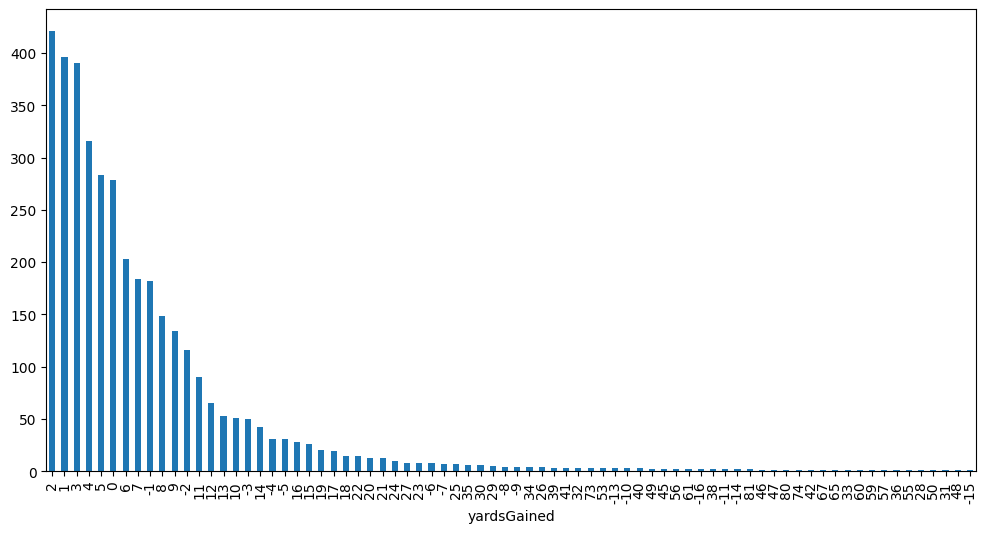

In [ ]:
print(runs.value_counts('yardsGained'))
runs.value_counts('yardsGained').plot(kind='bar', figsize=(12, 6))

In [ ]:
result = (runs['yardsGained'].value_counts(normalize=True) * 100).round(2)
result = result.reset_index()
result.columns = ['yardsGained', 'percent']
result

,yardsGained,percent
0,2,11.22
1,1,10.55
2,3,10.39
3,4,8.42
4,5,7.54
...,...,...
71,28,0.03
72,50,0.03
73,31,0.03
74,48,0.03


In [ ]:
total = 0
for n in range(-3, 3):
    percent = result[result['yardsGained'] == n]['percent'].values[0]
    total += percent
print(f"Total percentage: {total.round(2)}%")

Total percentage: 38.47%


In [ ]:
passes = first_downs[first_downs['playCategory'] == 'pass'][['yardsGained', 'clock', 'yardline', 'distance', 'playText']]
passes = passes.sort_values(by='yardsGained')
passes

,yardsGained,clock,yardline,distance,playText
14255,-100,"{'seconds': 34, 'minutes': 2}",11,10,"Ross Bowers pass intercepted for a TD Nick Fisher return for 100 yds for a TD, (James Stefanou KICK)"
11612,-46,"{'seconds': 23, 'minutes': 9}",22,10,"Jared Goff pass intercepted for a TD Adoree' Jackson return for 46 yds for a TD, (Alex Wood KICK)"
10731,-46,"{'seconds': 36, 'minutes': 1}",44,10,Luke Rubenzer pass intercepted Terrence Alexander return for 46 yds to the Cal 4
15629,-43,"{'seconds': 37, 'minutes': 3}",38,10,Chase Garbers pass intercepted Paulson Adebo return for 43 yds to the Cal 3
15032,-38,"{'seconds': 27, 'minutes': 8}",60,15,Brandon McIlwain pass intercepted Scottie Young Jr. return for 38 yds to the Cal 28
...,...,...,...,...,...
11008,75,"{'seconds': 50, 'minutes': 14}",25,10,"Jared Goff pass complete to Trevor Davis for 75 yds for a TD, (Matt Anderson KICK)"
9628,76,"{'seconds': 7, 'minutes': 6}",76,10,"Jared Goff pass complete to Trevor Davis for 76 yds for a TD, (James Langford KICK)"
11732,80,"{'seconds': 27, 'minutes': 7}",80,10,"Jared Goff pass complete to Bryce Treggs for 80 yds for a TD, (Matt Anderson KICK)"
9792,80,"{'seconds': 53, 'minutes': 11}",80,10,"Jared Goff pass complete to Bryce Treggs for 80 yds for a TD, (James Langford KICK)"


yardsGained
 0     1318
 9      145
 7      122
 8      122
 6      119
       ... 
-22       1
-29       1
-38       1
-43       1
 84       1
Name: count, Length: 93, dtype: int64


<Axes: xlabel='yardsGained'>

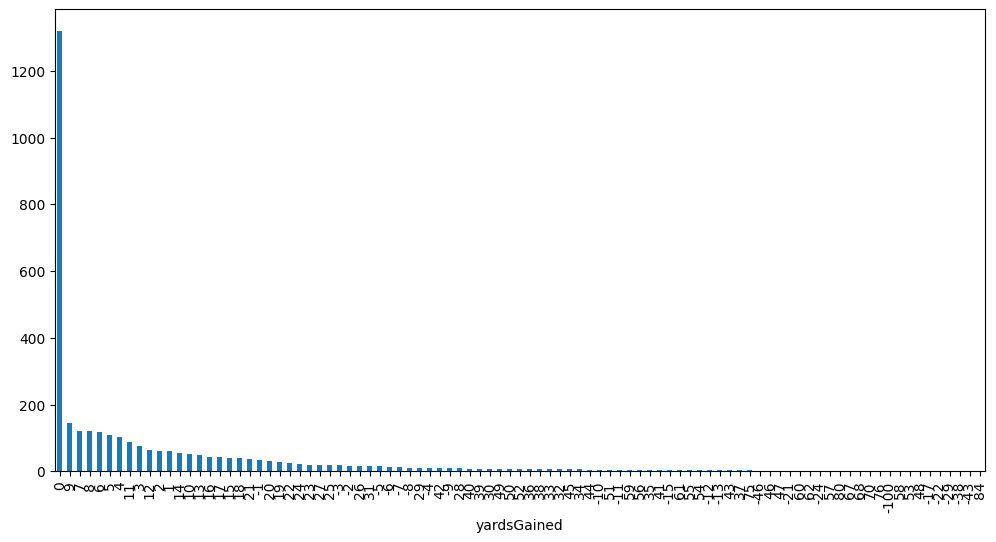

In [ ]:
print(passes.value_counts('yardsGained'))
passes.value_counts('yardsGained').plot(kind='bar', figsize=(12, 6))

In [ ]:
result = (passes['yardsGained'].value_counts(normalize=True) * 100).round(2)
result = result.reset_index()
result.columns = ['yardsGained', 'percent']
result

,yardsGained,percent
0,0,40.00
1,9,4.40
2,7,3.70
3,8,3.70
4,6,3.61
...,...,...
88,-22,0.03
89,-29,0.03
90,-38,0.03
91,-43,0.03


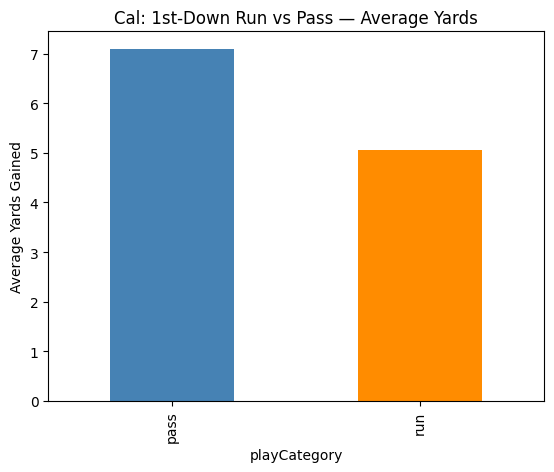

In [ ]:
first_down_yards = first_downs.groupby('playCategory')['yardsGained'].mean()

first_down_yards.plot(kind='bar', color=['steelblue', 'darkorange'])
plt.ylabel('Average Yards Gained')
plt.title('Cal: 1st-Down Run vs Pass — Average Yards')
plt.show()

In [ ]:
cal_offense_sorted = cal_offense_sorted[cal_offense_sorted['down'] > 0].copy()

cal_offense_sorted['newSet'] = cal_offense_sorted['down'] == 1
cal_offense_sorted['setId'] = cal_offense_sorted.groupby('driveId')['newSet'].cumsum()

In [ ]:
set_summary = cal_offense_sorted.groupby(['driveId', 'setId']).agg(
    firstPlayCategory=('playCategory', 'first'),
    firstDistance=('distance', 'first'),
    playsInSet=('playCategory', 'count'),
    totalYards=('yardsGained', 'sum'),
    year=('year', 'first')
).reset_index()

set_summary.head(20)

,driveId,setId,firstPlayCategory,firstDistance,playsInSet,totalYards,year
0,-232,1,run,10,1,13,2024
1,-232,2,pass,10,5,5,2024
2,-230,1,run,10,2,11,2024
3,-230,2,run,10,1,12,2024
4,-230,3,run,10,5,9,2024
5,-228,1,run,10,2,60,2024
6,-228,2,pass,10,1,15,2024
7,-225,1,run,10,2,11,2024
8,-225,2,run,10,4,26,2024
9,-225,3,pass,10,3,14,2024


In [ ]:
set_summary['converted'] = set_summary['totalYards'] >= set_summary['firstDistance']
run_pass_sets = set_summary[set_summary['firstPlayCategory'].isin(['run', 'pass'])]
run_conv = run_pass_sets[run_pass_sets['firstPlayCategory'] == 'run']['converted'].astype(int)
pass_conv = run_pass_sets[run_pass_sets['firstPlayCategory'] == 'pass']['converted'].astype(int)
stat, p = stats.ttest_ind(run_conv, pass_conv)
print(f"t-statistic: {stat}")
print(f"p-value: {p}")

t-statistic: -2.6975001309075193
p-value: 0.007002813775107372


In [ ]:
run_pass_sets = set_summary[set_summary['firstPlayCategory'].isin(['run', 'pass'])].copy()

first_yardline = cal_offense_sorted.groupby(['driveId', 'setId'])['yardline'].first().reset_index()
run_pass_sets = run_pass_sets.merge(first_yardline, on=['driveId', 'setId'])

run_pass_sets['fieldZone'] = pd.cut(
    run_pass_sets['yardline'],
    bins=[0, 40, 60, 100],
    labels=['own territory', 'midfield', 'opponent territory']
)

run_pass_sets.groupby(['fieldZone', 'firstPlayCategory'])['converted'].mean()

/var/folders/89/ththmnb54rvc6qk1pghznqv00000gn/T/ipykernel_32849/2017513602.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  run_pass_sets.groupby(['fieldZone', 'firstPlayCategory'])['converted'].mean()


fieldZone           firstPlayCategory
own territory       pass                 0.773810
                    run                  0.751523
midfield            pass                 0.744027
                    run                  0.724311
opponent territory  pass                 0.791200
                    run                  0.748822
Name: converted, dtype: float64

In [ ]:
for zone in ['own territory', 'midfield', 'opponent territory']:
    subset = run_pass_sets[run_pass_sets['fieldZone'] == zone]
    r = subset[subset['firstPlayCategory'] == 'run']['converted'].astype(int)
    p_ = subset[subset['firstPlayCategory'] == 'pass']['converted'].astype(int)
    stat, p = stats.ttest_ind(r, p_)
    print(f"{zone}: p = {p:.4f}, n_run={len(r)}, n_pass={len(p_)}")

own territory: p = 0.1811, n_run=1477, n_pass=1176
midfield: p = 0.3614, n_run=798, n_pass=879
opponent territory: p = 0.0089, n_run=1485, n_pass=1250


In [ ]:
run_pass_sets['distanceBucket'] = pd.cut(
    run_pass_sets['firstDistance'],
    bins=[0, 5, 10, 100],
    labels=['short (<5)', 'normal (10)', 'long (10+)']
)
print(run_pass_sets.groupby(['distanceBucket', 'firstPlayCategory'])['converted'].mean())

distanceBucket  firstPlayCategory
short (<5)      pass                 0.833333
                run                  0.896861
normal (10)     pass                 0.774911
                run                  0.739284
long (10+)      pass                 0.678571
                run                  0.623077
Name: converted, dtype: float64


/var/folders/89/ththmnb54rvc6qk1pghznqv00000gn/T/ipykernel_32849/750065155.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(run_pass_sets.groupby(['distanceBucket', 'firstPlayCategory'])['converted'].mean())


In [ ]:
run_pass_sets.groupby(['distanceBucket', 'firstPlayCategory'], observed=True).size()

distanceBucket  firstPlayCategory
short (<5)      pass                   60
                run                   223
normal (10)     pass                 3101
                run                  3406
long (10+)      pass                  140
                run                   130
dtype: int64

In [ ]:
for bucket in ['short (<5)', 'normal (10)', 'long (10+)']:
    subset = run_pass_sets[run_pass_sets['distanceBucket'] == bucket]
    r = subset[subset['firstPlayCategory'] == 'run']['converted'].astype(int)
    p_ = subset[subset['firstPlayCategory'] == 'pass']['converted'].astype(int)
    stat, p = stats.ttest_ind(r, p_)
    print(f"{bucket}: p = {p:.4f}, n_run={len(r)}, n_pass={len(p_)}")

short (<5): p = 0.1747, n_run=223, n_pass=60
normal (10): p = 0.0008, n_run=3406, n_pass=3101
long (10+): p = 0.3407, n_run=130, n_pass=140


In [ ]:
run_pass_sets[run_pass_sets['distanceBucket'] == 'normal (10)']['firstPlayCategory'].value_counts(normalize=True)

firstPlayCategory
run     0.523436
pass    0.476564
Name: proportion, dtype: float64

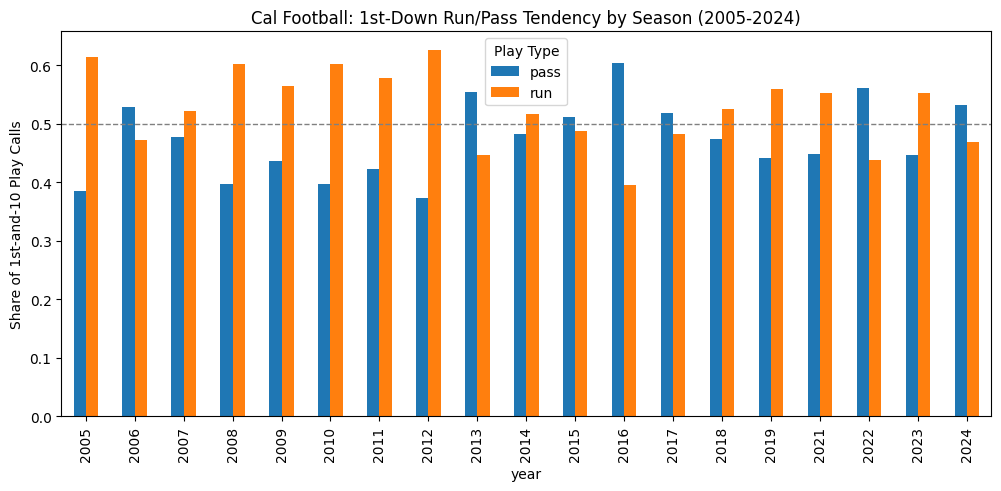

In [ ]:
freq_by_year_pct.plot(kind='bar', stacked=False, figsize=(12,5))
plt.ylabel('Share of 1st-and-10 Play Calls')
plt.title("Cal Football: 1st-Down Run/Pass Tendency by Season (2005-2024)")
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.legend(title='Play Type')
plt.show()

In [ ]:
run_pass_sets = set_summary[set_summary['firstPlayCategory'].isin(['run', 'pass'])].copy()

score_diff = cal_offense_sorted.groupby(['driveId', 'setId']).apply(
    lambda x: x['offenseScore'].iloc[0] - x['defenseScore'].iloc[0]
).reset_index(name='scoreDiff')

run_pass_sets = run_pass_sets.merge(score_diff, on=['driveId', 'setId'])

run_pass_sets['gameState'] = pd.cut(
    run_pass_sets['scoreDiff'],
    bins=[-100, -8, 8, 100],
    labels=['trailing', 'close game', 'leading']
)

print(run_pass_sets.groupby('gameState', observed=True)['firstPlayCategory'].value_counts(normalize=True))
print(run_pass_sets.groupby(['gameState', 'firstPlayCategory'], observed=True)['converted'].mean())

gameState   firstPlayCategory
trailing    pass                 0.585405
            run                  0.414595
close game  run                  0.546056
            pass                 0.453944
leading     run                  0.646732
            pass                 0.353268
Name: proportion, dtype: float64
gameState   firstPlayCategory
trailing    pass                 0.753463
            run                  0.743155
close game  pass                 0.772595
            run                  0.749394
leading     pass                 0.811024
            run                  0.735484
Name: converted, dtype: float64


/var/folders/89/ththmnb54rvc6qk1pghznqv00000gn/T/ipykernel_32849/2412897369.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  score_diff = cal_offense_sorted.groupby(['driveId', 'setId']).apply(


In [ ]:
leading = run_pass_sets[run_pass_sets['gameState'] == 'leading']
r = leading[leading['firstPlayCategory'] == 'run']['converted'].astype(int)
p_ = leading[leading['firstPlayCategory'] == 'pass']['converted'].astype(int)
stat, p = stats.ttest_ind(r, p_)
print(f"leading: p = {p:.4f}, n_run={len(r)}, n_pass={len(p_)}")

leading: p = 0.0013, n_run=930, n_pass=508


In [ ]:
run_pass_sets['leadSize'] = pd.cut(
    run_pass_sets['scoreDiff'],
    bins=[8, 16, 100],
    labels=['2-score lead (9-16)', '3+ score lead (17+)']
)
leading_only = run_pass_sets[run_pass_sets['gameState'] == 'leading']
print(leading_only.groupby(['leadSize', 'firstPlayCategory'], observed=True)['converted'].mean())

leadSize             firstPlayCategory
2-score lead (9-16)  pass                 0.824903
                     run                  0.709443
3+ score lead (17+)  pass                 0.796813
                     run                  0.756286
Name: converted, dtype: float64


In [ ]:
print(leading_only.groupby(['leadSize', 'firstPlayCategory'], observed=True).size())

for lead in ['2-score lead (9-16)', '3+ score lead (17+)']:
    subset = leading_only[leading_only['leadSize'] == lead]
    r = subset[subset['firstPlayCategory'] == 'run']['converted'].astype(int)
    p_ = subset[subset['firstPlayCategory'] == 'pass']['converted'].astype(int)
    stat, p = stats.ttest_ind(r, p_)
    print(f"{lead}: p = {p:.4f}, n_run={len(r)}, n_pass={len(p_)}")

leadSize             firstPlayCategory
2-score lead (9-16)  pass                 257
                     run                  413
3+ score lead (17+)  pass                 251
                     run                  517
dtype: int64
2-score lead (9-16): p = 0.0007, n_run=413, n_pass=257
3+ score lead (17+): p = 0.2115, n_run=517, n_pass=251


In [ ]:
wilcox_era = run_pass_sets[run_pass_sets['year'].between(2017, 2023)]
print(wilcox_era.groupby('firstPlayCategory')['converted'].mean())
r = wilcox_era[wilcox_era['firstPlayCategory'] == 'run']['converted'].astype(int)
p_ = wilcox_era[wilcox_era['firstPlayCategory'] == 'pass']['converted'].astype(int)
stat, p = stats.ttest_ind(r, p_)
print(f"Wilcox era: p = {p:.4f}, n_run={len(r)}, n_pass={len(p_)}")

firstPlayCategory
pass    0.762611
run     0.755338
Name: converted, dtype: float64
Wilcox era: p = 0.6951, n_run=1124, n_pass=1011


In [ ]:
wilcox_era = run_pass_sets[run_pass_sets['year'].between(2017, 2023)]

wilcox_leading = wilcox_era[wilcox_era['gameState'] == 'leading'].copy()

wilcox_leading['leadSize'] = pd.cut(
    wilcox_leading['scoreDiff'], bins=[8, 16, 100], labels=['2-score lead (9-16)', '3+ score lead (17+)']
)

two_score = wilcox_leading[wilcox_leading['leadSize'] == '2-score lead (9-16)']
r = two_score[two_score['firstPlayCategory'] == 'run']['converted'].astype(int)
p_ = two_score[two_score['firstPlayCategory'] == 'pass']['converted'].astype(int)
stat, p = stats.ttest_ind(r, p_)
print(f"Wilcox era, 2-score lead: p = {p:.4f}, n_run={len(r)}, n_pass={len(p_)}")
print(two_score.groupby('firstPlayCategory')['converted'].mean())

Wilcox era, 2-score lead: p = 0.1335, n_run=144, n_pass=78
firstPlayCategory
pass    0.794872
run     0.701389
Name: converted, dtype: float64


In [ ]:
season_summary = run_pass_sets[run_pass_sets['firstPlayCategory'].isin(['run', 'pass'])].groupby(
    ['year', 'firstPlayCategory'], observed=True
)['converted'].mean().unstack()

season_summary['gap'] = season_summary['pass'] - season_summary['run']
print(season_summary)

firstPlayCategory      pass       run       gap
year                                           
2005               0.689076  0.791045 -0.101969
2006               0.765101  0.773973 -0.008872
2007               0.780347  0.718447  0.061900
2008               0.694444  0.688073  0.006371
2009               0.765823  0.757009  0.008813
2010               0.706767  0.635922  0.070845
2011               0.773006  0.729730  0.043276
2012               0.737226  0.692641  0.044586
2013               0.730290  0.688119  0.042172
2014               0.804762  0.795556  0.009206
2015               0.836364  0.798122  0.038242
2016               0.852830  0.819588  0.033243
2017               0.791878  0.776042  0.015837
2018               0.757396  0.705263  0.052133
2019               0.700000  0.780105 -0.080105
2021               0.768212  0.725389  0.042823
2022               0.777778  0.748299  0.029478
2023               0.763636  0.791469 -0.027833
2024               0.841530  0.753165  0

In [ ]:
for yr in sorted(run_pass_sets['year'].dropna().unique()):
    subset = run_pass_sets[run_pass_sets['year'] == yr]
    r = subset[subset['firstPlayCategory'] == 'run']['converted'].astype(int)
    p_ = subset[subset['firstPlayCategory'] == 'pass']['converted'].astype(int)
    if len(r) < 10 or len(p_) < 10:
        print(f"{yr}: sample too small (n_run={len(r)}, n_pass={len(p_)})")
        continue
    stat, p = stats.ttest_ind(r, p_)
    print(f"{yr}: p = {p:.4f}, n_run={len(r)}, n_pass={len(p_)}, gap={p_.mean()-r.mean():.3f}")

2005: p = 0.0410, n_run=201, n_pass=119, gap=-0.102
2006: p = 0.8570, n_run=146, n_pass=149, gap=-0.009
2007: p = 0.1684, n_run=206, n_pass=173, gap=0.062
2008: p = 0.8982, n_run=218, n_pass=144, gap=0.006
2009: p = 0.8444, n_run=214, n_pass=158, gap=0.009
2010: p = 0.1786, n_run=206, n_pass=133, gap=0.071
2011: p = 0.3351, n_run=222, n_pass=163, gap=0.043
2012: p = 0.3639, n_run=231, n_pass=137, gap=0.045
2013: p = 0.3305, n_run=202, n_pass=241, gap=0.042
2014: p = 0.8110, n_run=225, n_pass=210, gap=0.009
2015: p = 0.3041, n_run=213, n_pass=220, gap=0.038
2016: p = 0.3398, n_run=194, n_pass=265, gap=0.033
2017: p = 0.7052, n_run=192, n_pass=197, gap=0.016
2018: p = 0.2681, n_run=190, n_pass=169, gap=0.052
2019: p = 0.0986, n_run=191, n_pass=140, gap=-0.080
2021: p = 0.3678, n_run=193, n_pass=151, gap=0.043
2022: p = 0.5287, n_run=147, n_pass=189, gap=0.029
2023: p = 0.5197, n_run=211, n_pass=165, gap=-0.028
2024: p = 0.0418, n_run=158, n_pass=183, gap=0.088


In [ ]:
ppa_by_play = cal_offense_sorted.groupby(['driveId', 'setId'])['ppa'].first().reset_index()
run_pass_sets = run_pass_sets.merge(ppa_by_play, on=['driveId', 'setId'])

two_score_full = run_pass_sets[
    (run_pass_sets['gameState'] == 'leading') &
    (run_pass_sets['scoreDiff'].between(9, 16))
]

r = two_score_full[two_score_full['firstPlayCategory'] == 'run']['ppa'].dropna()
p_ = two_score_full[two_score_full['firstPlayCategory'] == 'pass']['ppa'].dropna()
stat, p = stats.ttest_ind(r, p_)
print(f"p = {p:.4f}, n_run={len(r)}, n_pass={len(p_)}")
print(f"mean PPA — run: {r.mean():.3f}, pass: {p_.mean():.3f}")

p = 0.0049, n_run=402, n_pass=239
mean PPA — run: -0.001, pass: 0.248
